In [37]:
# Upload the Bank Marketing dataset for use in Google Colab.
from google.colab import files

uploaded = files.upload()

Saving bank.csv to bank (1).csv


In [38]:
# Load the Bank Marketing dataset into a pandas DataFrame.
import pandas as pd

df = pd.read_csv("Dataset/bank.csv")

print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [39]:
# Import libraries for data processing, visualization, model building, and evaluation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

np.random.seed(42)
tf.random.set_seed(42)

In [40]:
# Inspect the dataset structure, data types, and missing values.
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Shape: (11162, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 1

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [41]:
# Examine the distribution of the target variable.
print(df["deposit"].value_counts())
print(df["deposit"].value_counts(normalize=True))

deposit
no     5873
yes    5289
Name: count, dtype: int64
deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64


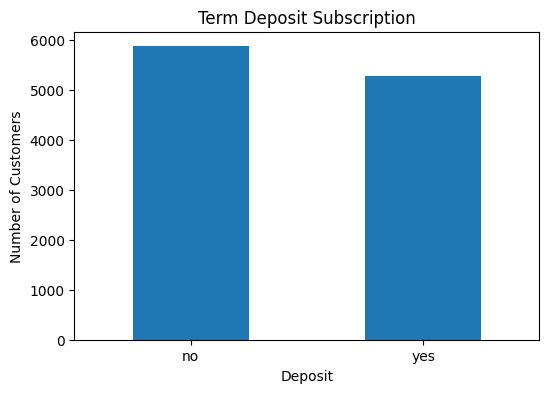

In [42]:
# Visualize the distribution of customers who subscribed to a term deposit.
df["deposit"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Term Deposit Subscription")
plt.xlabel("Deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

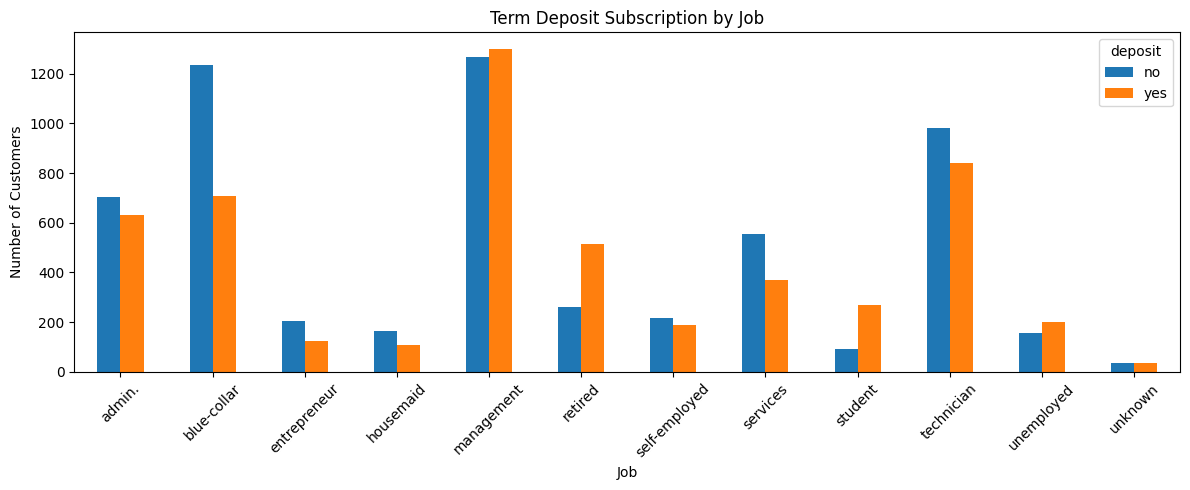

In [43]:
# Compare term-deposit subscriptions across different job categories.
pd.crosstab(
    df["job"],
    df["deposit"]
).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Term Deposit Subscription by Job")
plt.xlabel("Job")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Separate input features (X) from the target variable (y).
X = df.drop("deposit", axis=1)

y = df["deposit"].map({
    "no": 0,
    "yes": 1
})

print(y.value_counts())

deposit
0    5873
1    5289
Name: count, dtype: int64


In [45]:
# Convert categorical features into numerical values using one-hot encoding.
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical columns:")
print(categorical_columns.tolist())

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("\nShape after encoding:", X.shape)

X.head()

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Shape after encoding: (11162, 42)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,56,45,5,1467,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,41,1270,5,1389,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,55,2476,5,579,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,54,184,5,673,2,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [46]:
# Split the dataset into training and testing sets while preserving class proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (8929, 42)
Testing: (2233, 42)


In [47]:
# Standardize numerical features using statistics learned only from the training data.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)

(8929, 42)


In [48]:
# Define the neural network architecture and configure the optimizer and loss function.
def create_model(learning_rate=0.001):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(X_train.shape[1],)
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            16,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            8,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    # Binary crossentropy is used as the loss function for binary classification.
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [49]:
model = create_model()

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Perform a forward pass on one training sample using the untrained model.
sample = X_train[:1]

output = model(sample, training=False)

print("Predicted probability:", output.numpy()[0][0])

Predicted probability: 0.58942413


In [51]:
# Convert the predicted probability into a binary class using a 0.5 threshold.
probability = output.numpy()[0][0]

predicted_class = 1 if probability >= 0.5 else 0

print("Probability:", probability)
print("Predicted class:", predicted_class)

Probability: 0.58942413
Predicted class: 1


In [52]:
# Demonstrate one training step manually using TensorFlow's GradientTape.
demo_model = create_model(
    learning_rate=0.001
)

x_batch = tf.convert_to_tensor(
    X_train[:32],
    dtype=tf.float32
)

y_batch = tf.convert_to_tensor(
    y_train.iloc[:32].values.reshape(-1, 1),
    dtype=tf.float32
)

loss_function = tf.keras.losses.BinaryCrossentropy()

with tf.GradientTape() as tape:

    # Forward propagation

    predictions = demo_model(
        x_batch,
        training=True
    )

    loss = loss_function(
        y_batch,
        predictions
    )

# Backpropagation: calculate gradients of the loss with respect to model parameters.

gradients = tape.gradient(
    loss,
    demo_model.trainable_variables
)

# Update the model parameters using the calculated gradients.

demo_model.optimizer.apply_gradients(
    zip(
        gradients,
        demo_model.trainable_variables
    )
)

print("Loss:", loss.numpy())
print("Trainable variables:", len(demo_model.trainable_variables))
print("Gradients calculated:", len(gradients))

Loss: 0.723188
Trainable variables: 8
Gradients calculated: 8


In [53]:
# Train the neural network and track training and validation performance.
model = create_model(
    learning_rate=0.001
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7022 - loss: 0.5983 - val_accuracy: 0.7766 - val_loss: 0.4942
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8176 - loss: 0.4299 - val_accuracy: 0.8231 - val_loss: 0.4231
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8342 - loss: 0.3851 - val_accuracy: 0.8298 - val_loss: 0.4030
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8419 - loss: 0.3647 - val_accuracy: 0.8393 - val_loss: 0.3922
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8475 - loss: 0.3519 - val_accuracy: 0.8415 - val_loss: 0.3866
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8520 - loss: 0.3427 - val_accuracy: 0.8443 - val_loss: 0.3836
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8561 - loss: 0.3353 - val_accuracy: 0.8460 - val_loss: 0.3807
Epoch 8/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8579 - loss: 0.3292 - val_accuracy: 0.

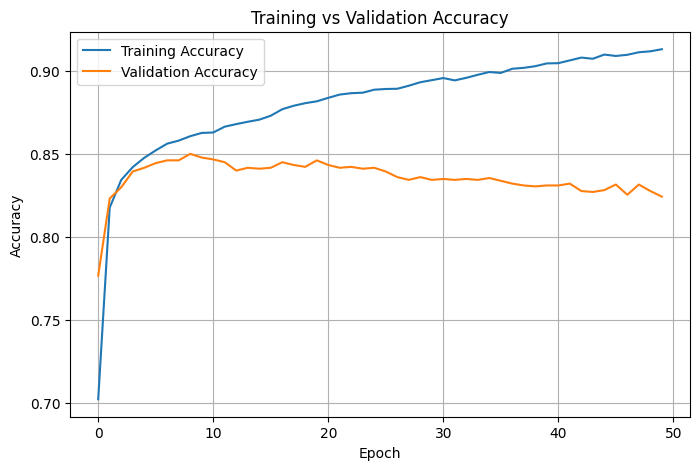

In [54]:
# Compare training and validation accuracy across epochs.
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

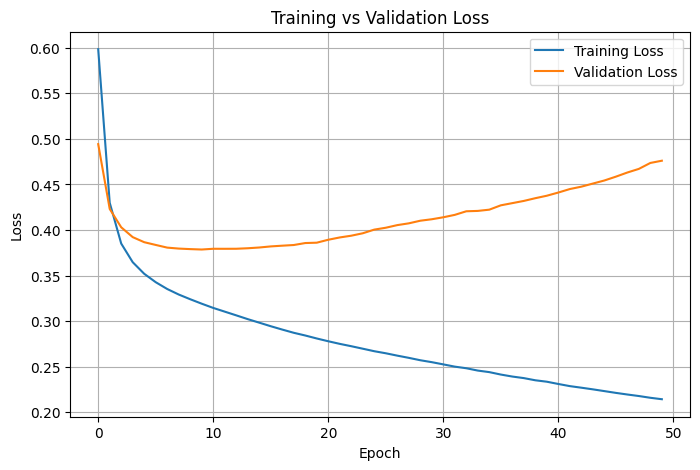

In [55]:
# Compare training and validation loss across epochs.
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [56]:
# Evaluate how different learning rates affect model performance.
learning_rates = [
    0.0001,
    0.001,
    0.01,
    0.1
]

lr_results = {}

for lr in learning_rates:

    print("\n---------------------------")
    print("Learning Rate:", lr)
    print("---------------------------")

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model_lr = create_model(
        learning_rate=lr
    )

    history_lr = model_lr.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    test_loss, test_accuracy = model_lr.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    lr_results[lr] = {
        "history": history_lr,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss
    }

    print(
        "Test Accuracy:",
        round(test_accuracy, 4)
    )

    print(
        "Test Loss:",
        round(test_loss, 4)
    )


---------------------------
Learning Rate: 0.0001
---------------------------
Test Accuracy: 0.841
Test Loss: 0.3753

---------------------------
Learning Rate: 0.001
---------------------------
Test Accuracy: 0.8316
Test Loss: 0.4674

---------------------------
Learning Rate: 0.01
---------------------------
Test Accuracy: 0.8173
Test Loss: 0.6823

---------------------------
Learning Rate: 0.1
---------------------------
Test Accuracy: 0.7631
Test Loss: 0.5575


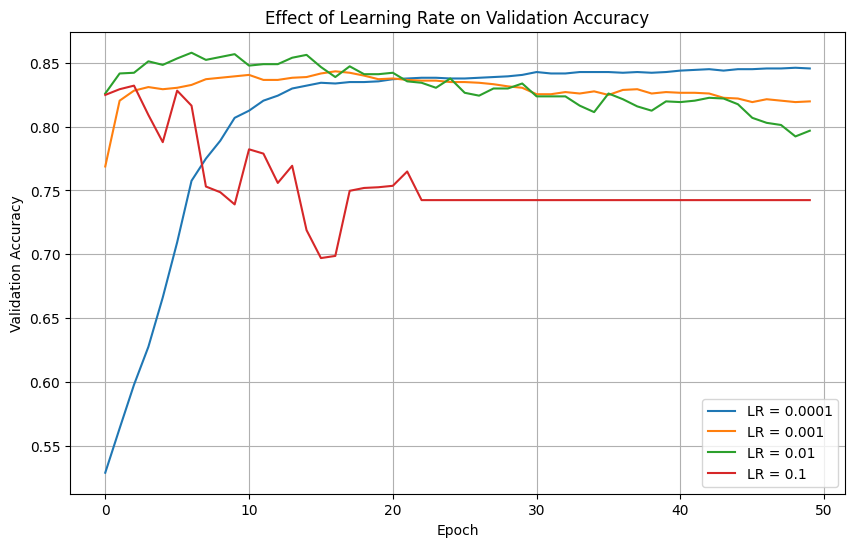

In [57]:
# Compare validation accuracy for different learning rates.
plt.figure(figsize=(10, 6))

for lr in learning_rates:

    plt.plot(
        lr_results[lr]["history"].history[
            "val_accuracy"
        ],
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title(
    "Effect of Learning Rate on Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

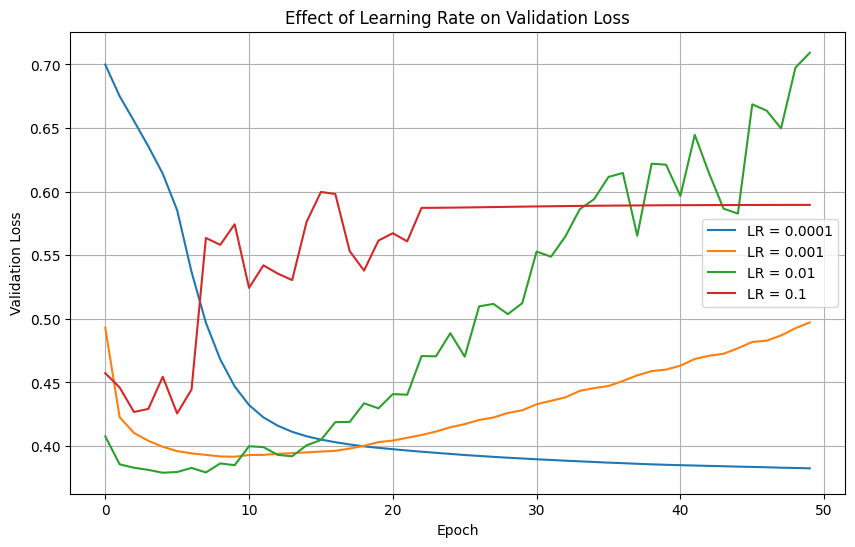

In [58]:
# Compare validation loss for different learning rates.
plt.figure(figsize=(10, 6))

for lr in learning_rates:

    plt.plot(
        lr_results[lr]["history"].history[
            "val_loss"
        ],
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Effect of Learning Rate on Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [59]:
# Summarize test performance for each learning rate.
lr_table = pd.DataFrame({
    "Learning Rate": learning_rates,

    "Test Accuracy": [
        lr_results[lr]["test_accuracy"]
        for lr in learning_rates
    ],

    "Test Loss": [
        lr_results[lr]["test_loss"]
        for lr in learning_rates
    ]
})

lr_table

,Learning Rate,Test Accuracy,Test Loss
0,0.0001,0.841021,0.375305
1,0.0010,0.831617,0.467400
2,0.0100,0.817286,0.682289
3,0.1000,0.763099,0.557470


In [61]:
best_lr = max(
    lr_results,
    key=lambda lr: max(lr_results[lr]["history"].history["val_accuracy"])
)

print("Best learning rate:", best_lr)

Best learning rate: 0.01


In [62]:
# Evaluate how the number of training epochs affects model performance.
epoch_values = [
    5,
    10,
    25,
    50,
    100
]

epoch_results = []

for epochs in epoch_values:

    print("\n----------------")
    print("Epochs:", epochs)
    print("----------------")

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model_epoch = create_model(
        learning_rate=best_lr
    )

    model_epoch.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=32,
        verbose=0
    )

    test_loss, test_accuracy = model_epoch.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    epoch_results.append({
        "Epochs": epochs,
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss
    })

    print(
        "Test Accuracy:",
        round(test_accuracy, 4)
    )


----------------
Epochs: 5
----------------
Test Accuracy: 0.8527

----------------
Epochs: 10
----------------
Test Accuracy: 0.8504

----------------
Epochs: 25
----------------
Test Accuracy: 0.8383

----------------
Epochs: 50
----------------
Test Accuracy: 0.8115

----------------
Epochs: 100
----------------
Test Accuracy: 0.8097


In [63]:
# Compare test accuracy for different numbers of epochs.
epoch_df = pd.DataFrame(
    epoch_results
)

epoch_df

,Epochs,Test Accuracy,Test Loss
0,5,0.852665,0.357565
1,10,0.850425,0.379191
2,25,0.838334,0.454411
3,50,0.811464,0.608681
4,100,0.809673,0.905831


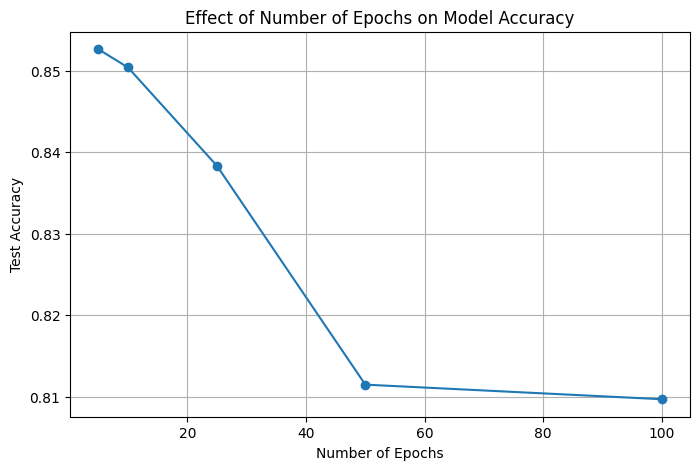

In [64]:
# Compare test loss for different numbers of epochs.
plt.figure(figsize=(8, 5))

plt.plot(
    epoch_df["Epochs"],
    epoch_df["Test Accuracy"],
    marker="o"
)

plt.xlabel("Number of Epochs")
plt.ylabel("Test Accuracy")

plt.title(
    "Effect of Number of Epochs on Model Accuracy"
)

plt.grid(True)

plt.show()

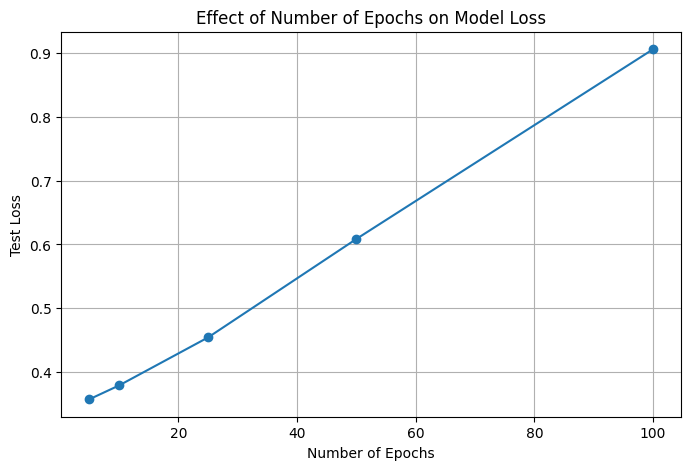

In [65]:
# Train the final model using the selected learning rate.
plt.figure(figsize=(8, 5))

plt.plot(
    epoch_df["Epochs"],
    epoch_df["Test Loss"],
    marker="o"
)

plt.xlabel("Number of Epochs")
plt.ylabel("Test Loss")

plt.title(
    "Effect of Number of Epochs on Model Loss"
)

plt.grid(True)

plt.show()

In [66]:
# Train the final model using the selected learning rate.
print("Using learning rate:", best_lr)

final_model = create_model(
    learning_rate=best_lr
)

final_history = final_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Using learning rate: 0.01
Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7978 - loss: 0.4433 - val_accuracy: 0.8242 - val_loss: 0.4128
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8400 - loss: 0.3740 - val_accuracy: 0.8343 - val_loss: 0.3929
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8492 - loss: 0.3587 - val_accuracy: 0.8376 - val_loss: 0.3837
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8508 - loss: 0.3484 - val_accuracy: 0.8371 - val_loss: 0.3818
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8561 - loss: 0.3420 - val_accuracy: 0.8432 - val_loss: 0.3784
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8604 - loss: 0.3361 - val_accuracy: 0.8443 - val_loss: 0.3765
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8600 - loss: 0.3308 - val_accuracy: 0.8427 - val_loss: 0.3816
Epoch 8/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8646 - loss:

In [67]:
# Evaluate the final model on the unseen test set.
test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    "Final Test Accuracy:",
    round(test_accuracy, 4)
)

print(
    "Final Test Loss:",
    round(test_loss, 4)
)

Final Test Accuracy: 0.8204
Final Test Loss: 0.6799


In [68]:
# Generate probability predictions for the test set.
y_probability = final_model.predict(
    X_test
)

print(y_probability[:10])

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[7.7289081e-01]
 [9.9160695e-01]
 [9.8948133e-01]
 [6.0146279e-09]
 [5.6839633e-01]
 [1.8285701e-12]
 [6.6939238e-06]
 [5.6998316e-02]
 [8.9994901e-01]
 [9.6020633e-01]]


In [69]:
# Convert predicted probabilities into binary class labels.
y_pred = (
    y_probability.flatten() >= 0.5
).astype(int)

print(y_pred[:20])

[1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 0 0 1]


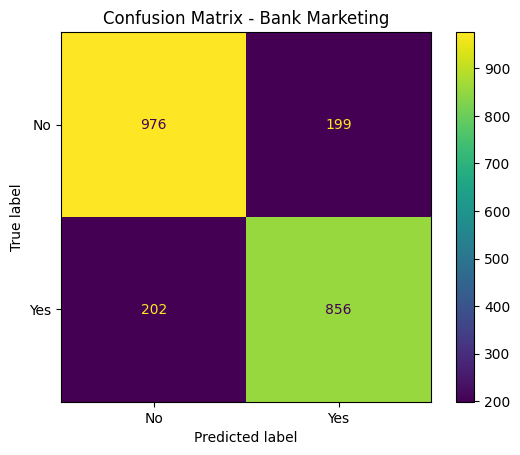

In [70]:
# Visualize the final model's classification performance using a confusion matrix.
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()

plt.title(
    "Confusion Matrix - Bank Marketing"
)

plt.show()